# rust-NMF — quickstart

Rust port of R's `NMF` package. Bit-equivalent multiplicative-update
algorithms (`brunet`, `lee`, `offset`, `nsNMF`), parallelised with
rayon. Drop-in replacement for the inner update loops of `NMF::nmf()`.

This notebook walks through:
1. Building a synthetic non-negative matrix.
2. Running each of the four built-in algorithms.
3. Inspecting the `NMFResult` (`W`, `H`, `n_iter`, `deviances`).
4. Reusing the same factorisation for downstream sklearn-style work.

In [1]:
import numpy as np
import nmf_rs

rng = np.random.default_rng(0)
n, p, rank = 200, 60, 5
W_true = rng.uniform(0.1, 1.5, (n, rank))
H_true = rng.uniform(0.1, 1.5, (rank, p))
V = W_true @ H_true + rng.uniform(0, 0.05, (n, p))
V.shape, V.min(), V.max()

((200, 60), 0.6152416663367443, 8.061756004056358)

## Random initial factors

The `nmf()` driver accepts either explicit `W0`/`H0` (recommended for
reproducibility) or a `seed` argument that triggers in-Python random
init. *Note*: NumPy's RNG is not bit-equal to R's `runif()`, so for
parity with R you must generate `W0`/`H0` in R and pass them in.

In [2]:
W0, H0 = nmf_rs.random_init(V, rank, seed=42)
W0.shape, H0.shape

((200, 5), (5, 60))

## Brunet (KL divergence) — the default

200 multiplicative-update iterations. R's `NMF::nmf(method='brunet')`
uses the same algorithm under the hood.

In [3]:
res = nmf_rs.nmf(V, rank=rank, method='brunet',
                 W0=W0, H0=H0, max_iter=200)
print(res)
print('recon error :', np.linalg.norm(V - res.fitted()))

NMFResult(method='brunet', n=200, p=60, rank=5, n_iter=200)
recon error : 9.11162723892749


## Lee (Frobenius) and the rest

All four built-in algorithms share the same `nmf()` entry-point. The
`offset` algorithm also returns an offset vector accessible as
`res.offset` — `fitted()` automatically adds it back.

In [4]:
for method in ('brunet', 'lee', 'offset', 'nsNMF'):
    res = nmf_rs.nmf(V, rank=rank, method=method,
                     W0=W0, H0=H0, max_iter=200)
    err = np.linalg.norm(V - res.fitted())
    extras = '' if res.offset is None else f'  off=[{res.offset.min():.2f}, {res.offset.max():.2f}]'
    print(f'{method:8s}  iters={res.n_iter}  ||V-WH|| = {err:.4f}{extras}')

brunet    iters=200  ||V-WH|| = 9.1116
lee       iters=200  ||V-WH|| = 8.0928
offset    iters=200  ||V-WH|| = 8.4113  off=[0.61, 2.21]
nsNMF     iters=200  ||V-WH|| = 30.8650


## Stationary stopping

Set `stop='stationary'` to replicate R's `nmf.stop.stationary` semantics
— the run halts when the objective value is flat over a window of
`check_niter` checks taken every `check_interval` iterations.

In [5]:
res = nmf_rs.nmf(V, rank=rank, method='brunet',
                 W0=W0, H0=H0, max_iter=2000,
                 stop='stationary',
                 stationary_th=1e-6,
                 check_interval=10, check_niter=10)
print('stopped after', res.n_iter, 'iters; final KL =', res.deviances[-1])
len(res.deviances)

stopped after 2000 iters; final KL = 0.5964519986834893


2001

## Plotting the loss curve

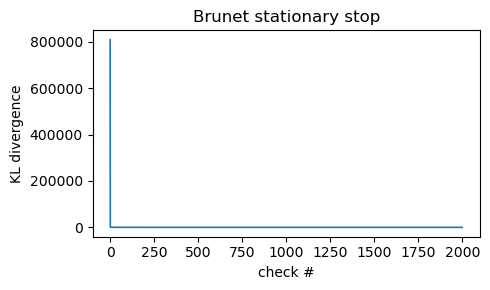

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(res.deviances, lw=1.2)
ax.set_xlabel('check #'); ax.set_ylabel('KL divergence')
ax.set_title('Brunet stationary stop'); fig.tight_layout()

## Single-step kernels

If you want full control over the iteration loop, the per-step kernels
are also exposed as bit-equivalent updates of R's `std.divergence.update.{h,w}`
and `std.euclidean.update.{h,w}`.

In [7]:
H1 = nmf_rs.update_h_brunet(V, W0, H0)
W1 = nmf_rs.update_w_brunet(V, W0, H1)
print('one Brunet step ΔKL =',
      float(((V * np.log(np.where(V>0, V/(W0@H0+1e-30), 1)) - V + W0@H0).sum()) -
            ((V * np.log(np.where(V>0, V/(W1@H1+1e-30), 1)) - V + W1@H1).sum())))

one Brunet step ΔKL = 808788.7003988085


## See also

- [`benchmark_vs_R.ipynb`](benchmark_vs_R.ipynb) — bit-equivalence and
  speed comparison vs R `NMF`.
- The R reference fixtures live under `tests/data/` and are produced by
  `tests/reference_nmf.R`.